# Fake Job Postings

In [1]:
import pandas as pd

df_jobs = pd.read_csv('data/fake_job_postings.csv')
df_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

- quasi 18k righe
- 18 colonne
- `fraudulent` è il target 

---

- bisogna capire quali features sono utili
- useremo tecniche NLP per analizzare gli annunci (valori testuali)
- dobbiamo vedere i valori null
  - i null sono solo nelle colonne di testo

In [2]:
null_columns = df_jobs.columns[df_jobs.isnull().any()]
null_columns

Index(['location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function'],
      dtype='object')

In [3]:
df_jobs.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Non tutte le colonne di testo devono essere trattate allo stesso modo. 
- employment_type è categorica
- description è testo libero

Le colonne categoriche saranno riempite (dove null) ad esempio con "Other" (già presente), "Unspecified" o "Unknown". Scegliamo "Unknown" per ora.

Le colonne a testo libero possiamo usare "Missing".

In [4]:
#count distinct values in each column
df_jobs[null_columns].nunique()

location                3105
department              1337
salary_range             874
company_profile         1709
description            14801
requirements           11967
benefits                6204
employment_type            5
required_experience        7
required_education        13
industry                 131
function                  37
dtype: int64

In [5]:
cols_to_fill_unknown = ['department', 'salary_range', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
# columns are "categorical" in nature, so fill NaN with 'Unknown'
df_jobs[cols_to_fill_unknown] = df_jobs[cols_to_fill_unknown].fillna('Unknown')

In [6]:
cols_to_fill_missing = ['description', 'requirements', 'benefits', 'company_profile', 'location']
# columns are more free-form text, so fill NaN with 'Missing'
df_jobs[cols_to_fill_missing] = df_jobs[cols_to_fill_missing].fillna('Missing')

In [7]:
df_jobs.isnull().sum()

job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [8]:
print("Fraudulent job postings:")
print(df_jobs['fraudulent'].value_counts())

Fraudulent job postings:
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [9]:
# Save the cleaned DataFrame to a new CSV file (can do Data Viz in PowerBI or similar instead of Python)
df_jobs.to_csv('data/fake_job_postings_cleaned.csv', index=False)

## Data Viz

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
def show_barplot_vs_fraudulent(x, xlabel, rotation=45):
    plt.figure(figsize=(10,6))
    sns.barplot(df_jobs, x=x, y='fraudulent', estimator='sum') #sum counts the number of fraudulent postings per category since 'fraudulent' is 0/1
    plt.title('Fraudulent Job Postings by ' + xlabel)
    plt.xlabel(xlabel)
    plt.ylabel('Number of Fraudulent Postings')
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

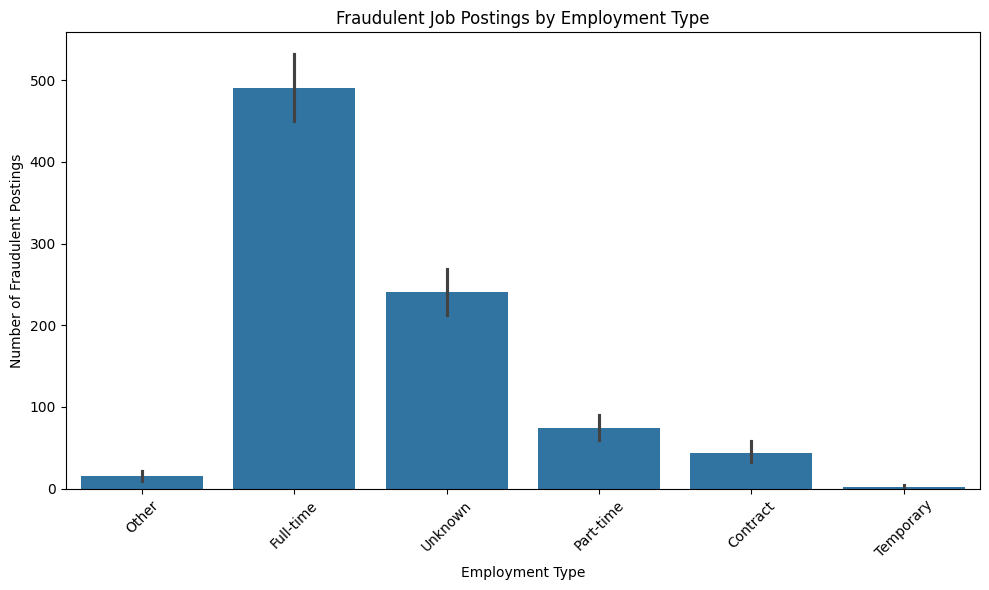

In [12]:
show_barplot_vs_fraudulent('employment_type', 'Employment Type')

Most fraudulent postings are full-time. Temporary is the least common type used for fraudulent postings. 

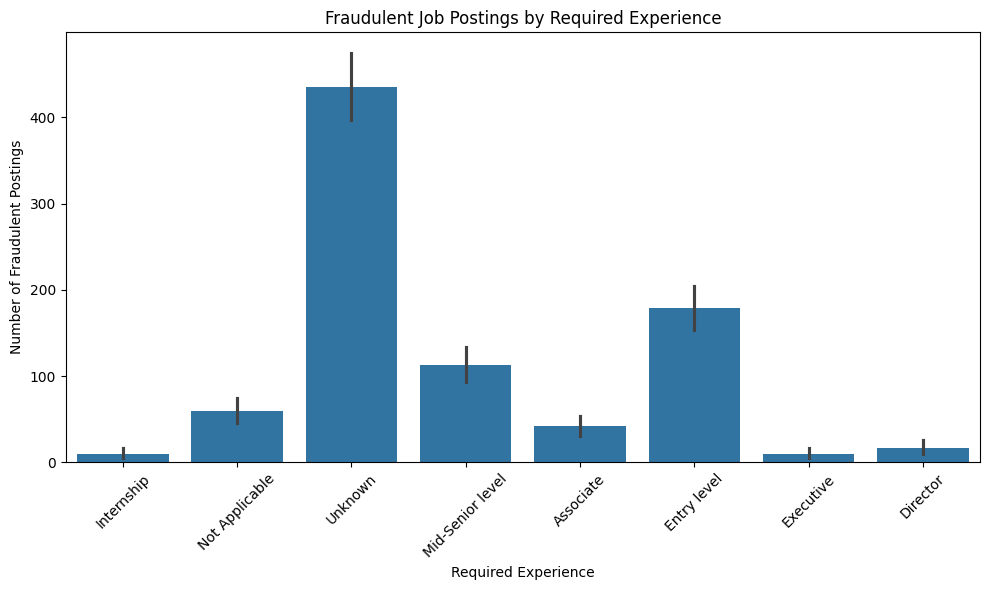

In [13]:
show_barplot_vs_fraudulent('required_experience', 'Required Experience')

Most fraudulent postings don't specify required experience, few are Internship, Executive or Director "roles"

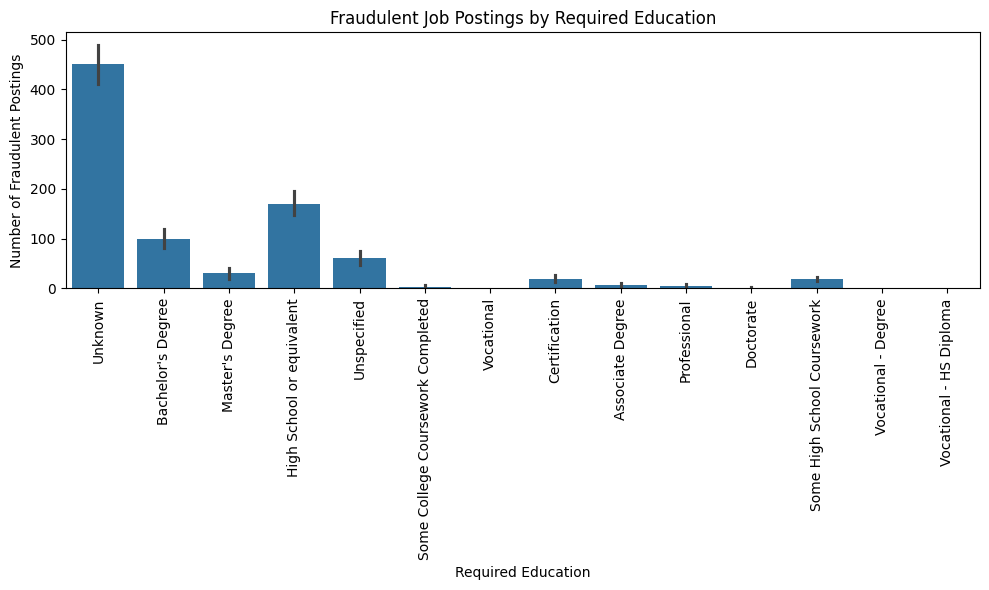

In [14]:
show_barplot_vs_fraudulent('required_education', 'Required Education', rotation=90)

There is greater probability that a fraudulent job posting doesn't specify education requirements. Less so for Vocational and Doctorate.

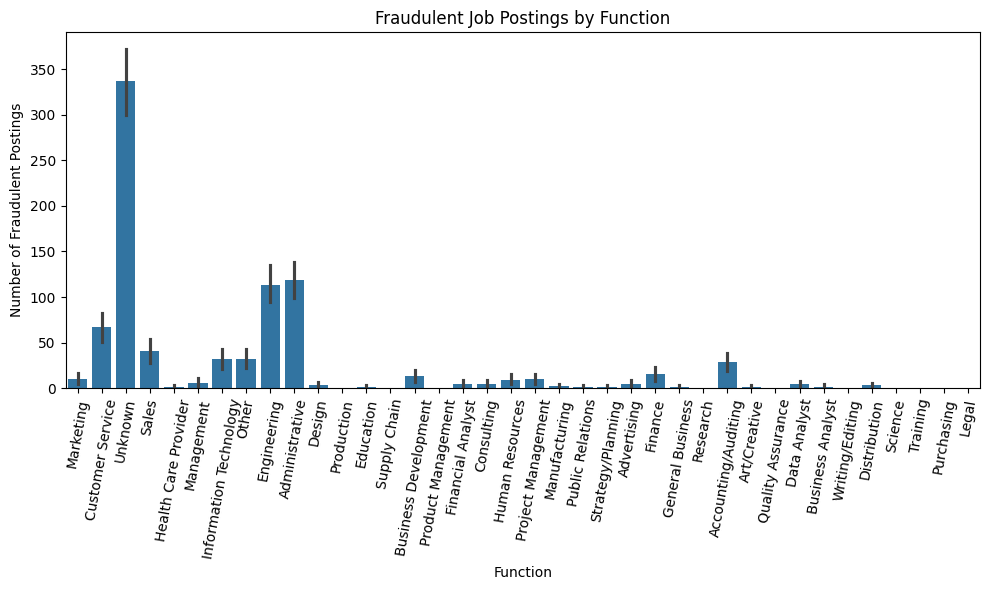

In [15]:
show_barplot_vs_fraudulent('function', 'Function', rotation=80)

In [16]:
#list salary_range values
salary_range_values = df_jobs['salary_range'].unique()
salary_range_values.sort()
salary_range_values

array(['0-0', '0-1', '0-1000', '0-100000', '0-110406', '0-115',
       '0-120000', '0-1200000', '0-12500', '0-130000', '0-15000',
       '0-150000', '0-16000', '0-180000', '0-2000', '0-20000', '0-24000',
       '0-25000', '0-268', '0-30000', '0-32000', '0-34300', '0-35000',
       '0-38000', '0-43500', '0-45000', '0-48000', '0-50000', '0-60000',
       '0-65000', '0-70000', '0-90000', '0-92000', '0-9360000', '0-95000',
       '10-Nov', '10-Oct', '100-120', '100-150', '100-200', '1000-1000',
       '1000-10000', '1000-1100', '1000-1400', '1000-1500', '1000-2000',
       '1000-20000', '1000-26000', '1000-3000', '1000-4000', '1000-5000',
       '1000-6000', '10000-10000', '10000-100000', '10000-12000',
       '10000-120000', '10000-14000', '10000-15000', '10000-16000',
       '10000-18000', '10000-20000', '10000-22000', '10000-25000',
       '10000-250000', '10000-30000', '100000-110000', '100000-115000',
       '100000-117000', '100000-120000', '100000-125000', '100000-130000',
       '1

The values in salary_range are also not very good, there are dates mixed in!

Again, fraudulent jobs are more likely to be with unknown job functions. Engineering and Administrative are next most likely.

Text(0.5, 1.0, 'Fraudulent Job Postings by Description Length')

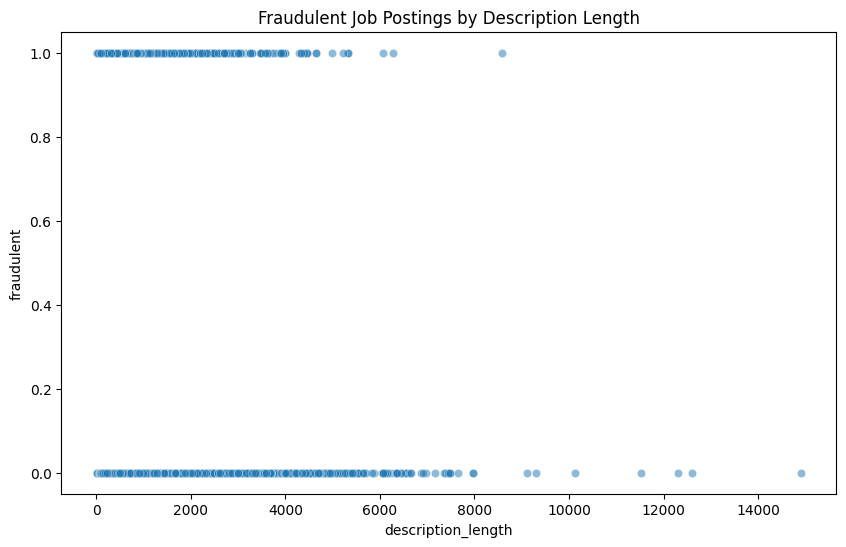

In [17]:
# sum of fraudulent postings by length of description
df_jobs['description_length'] = df_jobs['description'].apply(len)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_jobs, x='description_length', y='fraudulent', alpha=0.5)
plt.title('Fraudulent Job Postings by Description Length')  

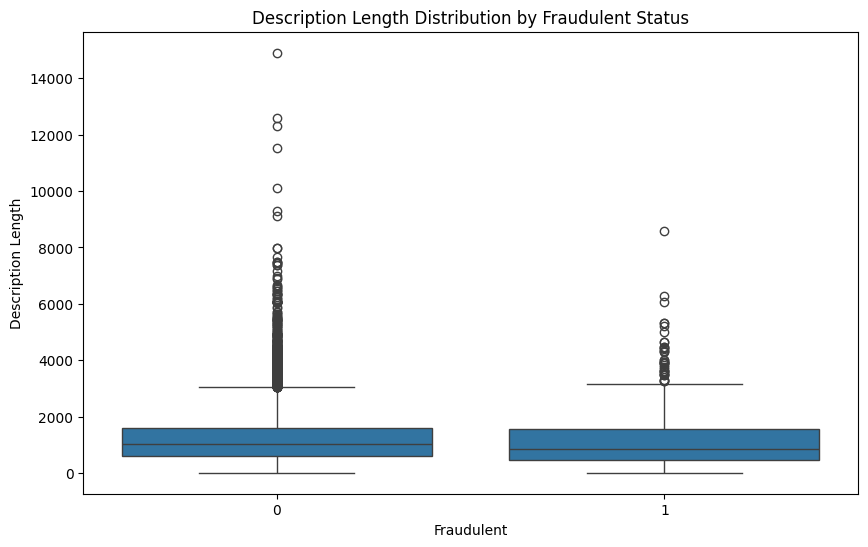

In [18]:
# violin plot of description length by fraudulent
plt.figure(figsize=(10,6))
sns.boxplot(data=df_jobs, x='fraudulent', y='description_length')
plt.title('Description Length Distribution by Fraudulent Status')
plt.xlabel('Fraudulent')
plt.ylabel('Description Length')
plt.show()

The length of a fraudulent job posting will probably not exceed 8000 characters and most are under 3000. They follow the average length of postings. However, a longer description will probably not be fraudulent.

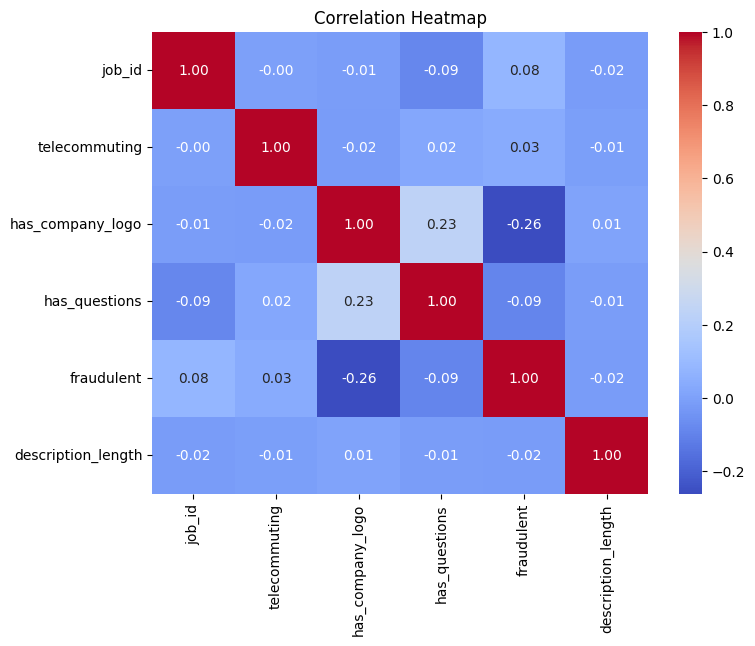

In [19]:
# heatmap of correlations, accounting for text columns
plt.figure(figsize=(8,6))
corr = df_jobs.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


While not necessarily strongly related, postings with a company logo are less likely to be fraudulent

job_id, telecommuting and has_questions are generally unrelated. 

## Pre-processing

Ci sono alcuni accorgimenti che possiamo fare per prepare i dati per l'analisi e la modellazione.

Uno di questi è la rimozione di caratteri speciali e numeri dai testi degli annunci, in modo da mantenere solo le parole.

Potremmo anche rimuovere le stopwords e le parole troppo comuni, in modo da ridurre il rumore nei dati (non lo faremo qui).

Per rimuovere caratteri speciali e numeri dai testi potremmo utilizzare Regex (Regular Expressions)

Alcuni appunti:
- `[0-9]` = tutti i caratteri numerici tra 0 e 9 
- `[a-zA-Z]`= tutti i caratteri alfabetici (minuscole e maiuscole)
- `[^a-zA-Z-0-9]` = tutti i caratteri *non* alfanumerici
- `\s` = spazi (whitespace)
- `+` = uno o più del carattere precedente
- `*` = zero o più del carattere precedente
- `\d` = decimal
- `\w` = caratteri alfanumerici o underscore

In [20]:
import re

def text_cleaning(text):
    # remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    return text.lower()

In [21]:
text_columns = ['description', 'requirements', 'benefits', 'company_profile', 'location']

for col in text_columns:
    df_jobs[col] = df_jobs[col].apply(text_cleaning)

In [22]:
df_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17880 non-null  object
 3   department           17880 non-null  object
 4   salary_range         17880 non-null  object
 5   company_profile      17880 non-null  object
 6   description          17880 non-null  object
 7   requirements         17880 non-null  object
 8   benefits             17880 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      17880 non-null  object
 13  required_experience  17880 non-null  object
 14  required_education   17880 non-null  object
 15  industry             17880 non-null  object
 16  func

## Modellazione

Per modellare i dati useremo un modello di classificazione basato su Random Forest o Logistic Regression.

Dobbiamo anche considerare che il dataset è perlopiù testo. Paragonabile quindi ad un documento, dobbiamo trasformarlo in vettori di features numeriche. Per fare questo useremo una tecnica NLP come TF-IDF.

Alcuni appunti su TF-IDF:
- TF-IDF sta per Term Frequency-Inverse Document Frequency
- TF misura la frequenza di una parola in un documento
- IDF misura l'importanza di una parola in un corpus di documenti
- TF-IDF è il prodotto di TF e IDF
- TF-IDF assegna un punteggio a ciascuna parola in base alla sua frequenza nel documento e alla sua rarità nel corpus
- Le parole comuni ricevono un punteggio basso, mentre le parole rare ricevono un punteggio alto
- TF-IDF quindi è molto utile per estrarre informazioni rilevanti dai testi

In [ ]:
# import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

In [26]:
# Use TfidfVectorizer to convert text data into numerical format
tfidfvectorizer = TfidfVectorizer(max_features=5000)

In [27]:
# unify text columns into a single feature column
df_jobs['combined_text'] = df_jobs[text_columns].agg(' '.join, axis=1) # join each column's text with space

In [ ]:
# create the model DataFrame
df_model = df_jobs[['combined_text', 'has_company_logo', 'fraudulent']]
df_model.head()

,combined_text,has_company_logo,fraudulent
0,food a fastgrowing james beard awardwinning on...,1,0
1,organised focused vibrant awesomedo you hav...,1,0
2,our client located in houston is actively seek...,1,0
3,the company esri environmental systems resear...,1,0
4,job title itemization review managerlocation f...,1,0


In [30]:
df_jobs.loc[4]

job_id                                                                 5
title                                                Bill Review Manager
location                                                us fl fort worth
department                                                       Unknown
salary_range                                                     Unknown
company_profile        spotsource solutions llc is a global human cap...
description            job title itemization review managerlocation f...
requirements           qualificationsrn license in the state of texas...
benefits                                           full benefits offered
telecommuting                                                          0
has_company_logo                                                       1
has_questions                                                          1
employment_type                                                Full-time
required_experience                                

In [31]:
X = df_model[['combined_text', 'has_company_logo']]
y = df_model['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Abbiamo bisogno di bilanciare il dataset. Una tecnica (oltre stratify) è SMOTE (Synthetic Minority Over-sampling Technique).

Alcuni appunti su SMOTE:
- SMOTE è una tecnica di over-sampling che crea campioni sintetici della classe minoritaria
- SMOTE funziona creando nuovi campioni che sono combinazioni lineari dei campioni esistenti
- SMOTE è molto utile per bilanciare i dati e migliorare le prestazioni del modello
- Tuttavia, SMOTE può anche introdurre rumore nei dati, quindi è importante utilizzarlo con cautela

In [33]:
class_distribution = y_train.value_counts(normalize=True)
class_distribution

fraudulent
0    0.952111
1    0.047889
Name: proportion, dtype: float64

In [34]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# usiamo SMOTE per bilanciare il dataset
from imblearn.over_sampling import SMOTE

In [40]:
X_tfidf_train = tfidfvectorizer.fit_transform(X_train['combined_text'])

In [41]:
# facciamo una verifica che SMOTE funziona
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_tfidf_train, y_train)

# check new class distribution
resampled_class_distribution = y_train_resampled.value_counts(normalize=True)
resampled_class_distribution

fraudulent
0    0.5
1    0.5
Name: proportion, dtype: float64

In [46]:
#show X_tfidf_train as DataFrame
X_tfidf_train_df = pd.DataFrame(X_tfidf_train.toarray(), columns=tfidfvectorizer.get_feature_names_out())
X_tfidf_train_df.head()

,aan,ab,abc,abilities,ability,able,about,above,abreast,abroad,...,να,που,σε,στην,στο,την,της,το,του,των
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.018530,0.000000,0.018997,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.046043,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.028856,0.000000,0.029583,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Creazione del Modello

1. tf-idf sulla colonna combined_text
2. has_company_logo resta invariata
3. applicare SMOTE (dopo tf-idf)
4. Random Forest per la classificazione (o altro modello)

In [54]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer([
    ('tfidf', TfidfVectorizer(max_features=5000), 'combined_text'),
    ],
    remainder='passthrough')

pipeline = ImbPipeline([
    ('transform', transformer),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)
pipeline

,steps,"[('transform', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
# test the model
y_pred = pipeline.predict(X_test)
# score the model
pipeline.score(X_test, y_test)

0.9798657718120806

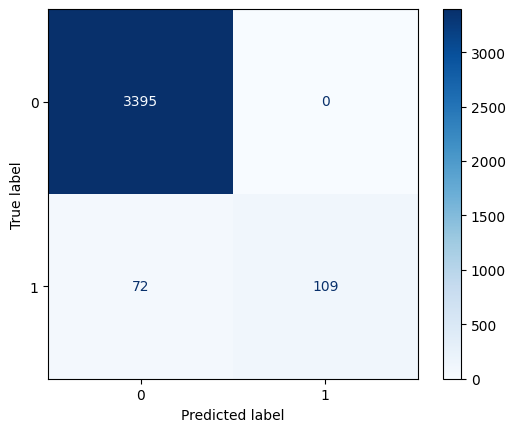

In [57]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)